In [5]:
%matplotlib
import numpy as np
import pandas as pd
import random
import plotly.figure_factory as ff
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

Using matplotlib backend: module://ipympl.backend_nbagg


In [17]:
s1_Range_lis = [0,1]
s2_Range_lis = [0,1]
b1_Range_lis = [0,1]

nCi_Range_lis = [0.5,2.0]
nIt_Range_lis = [1.0,2.0]

def nCi_func(s1_sca,b1_sca,nCi_Range_lis):
    nCi_sca = (nCi_Range_lis[0]+((nCi_Range_lis[1]-nCi_Range_lis[0])*s1_sca))*b1_sca
    return nCi_sca

def nIt_func(s2_sca,b1_sca,nIt_Range_lis):
    nIt_sca = (nIt_Range_lis[0]+((nIt_Range_lis[1]-nIt_Range_lis[0])*s2_sca))*(1-b1_sca)
    return nIt_sca

In [18]:
ptot_sca = 1000

s1_lis = []
s2_lis = []
b1_lis = []
nCi_lis = []
nIt_lis = []

for i in range(ptot_sca):
    s1_sca = random.random()
    s2_sca = random.random()
    b1_sca = random.random()
    nCi_sca = nCi_func(s1_sca,b1_sca,nCi_Range_lis)
    nIt_sca = nIt_func(s2_sca,b1_sca,nIt_Range_lis)
    s1_lis.append(s1_sca)
    s2_lis.append(s2_sca)
    b1_lis.append(b1_sca)
    nCi_lis.append(nCi_sca)
    nIt_lis.append(nIt_sca)

s1_arr = np.array(s1_lis)
s2_arr = np.array(s2_lis)
b1_arr = np.array(b1_lis)
nCi_arr = np.array(nCi_lis)
nIt_arr = np.array(nIt_lis)

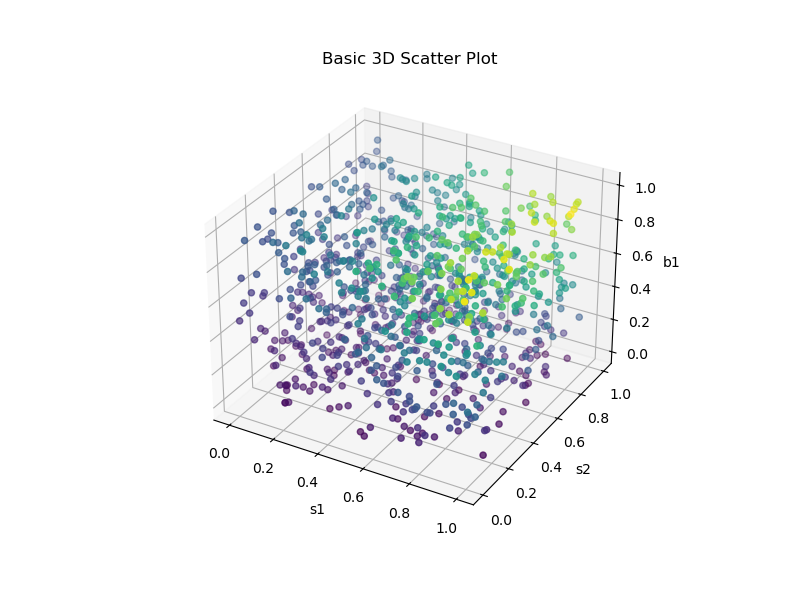

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
x = s1_arr
y = s2_arr
z = b1_arr

# Create a figure and 3D axis
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot
ax.scatter3D(x, y, z, c=nCi_arr, marker='o')

# Labels
ax.set_xlabel('s1')
ax.set_ylabel('s2')
ax.set_zlabel('b1')
ax.set_title('Basic 3D Scatter Plot')

plt.show()

In [ ]:
# Original Code which is adapted.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import mpl_toolkits.mplot3d.art3d as art3d

def tilted_heatmap_in_3d(arr, z, cmap=plt.cm.RdYlGn, ax=None):
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')

    for ii, row in enumerate(arr):
        for jj, value in enumerate(row):
            r = Rectangle((ii-0.5, jj-0.5), 1, 1, color=cmap(value))
            ax.add_patch(r)
            art3d.pathpatch_2d_to_3d(r, z=z, zdir="z")

    ax.set_xlim(-1, ii+1)
    ax.set_ylim(-1, jj+1)
    ax.set_zlim(0, 2*z)
    ax.get_figure().canvas.draw()
    
    ax.view_init(elev=90, azim=0)

if __name__ == '__main__':

    # tilted_heatmap_in_3d(arr=np.random.rand(3, 3), z=15)
    tilted_heatmap_in_3d(arr=np.array([[0.6,0.7,0.8],[0.5,0.5,0.5],[0.5,0.5,0.5]]), z=15)
    plt.show()

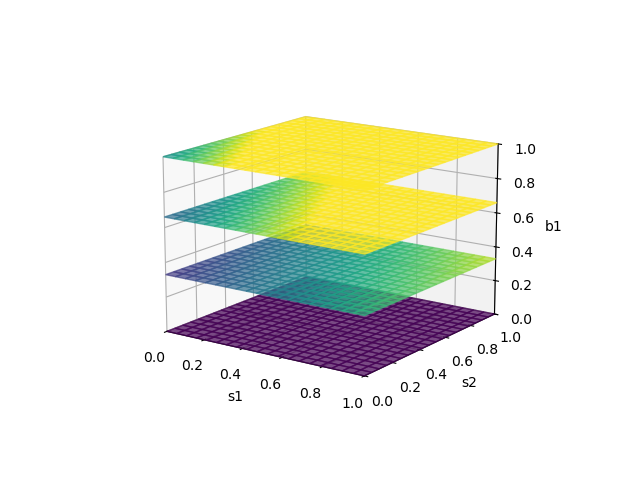

In [113]:
# Citric Acid Stoichiometries

from matplotlib.patches import Rectangle
import mpl_toolkits.mplot3d.art3d as art3d

cmap=plt.colormaps['viridis']

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

n = 20

s1Graduations = np.linspace(0,1,n)[0:n-1]
s2Graduations = np.linspace(0,1,n)[0:n-1]

b1_sca = 0.0

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Upper = s1Grad_sca + (1/(n-1))
        s1Lower = s1Grad_sca
        s2Upper = s2Grad_sca + (1/(n-1))
        s2Lower = s2Grad_sca

        samples = 10
        s1values = []
        s2values = []
        for i in range(samples):
            s1values.append(random.random() * (s1Upper - s1Lower) + s1Lower)
            s2values.append(random.random() * (s2Upper - s2Lower) + s2Lower)
        nCiValues = []
        for i,j in zip(s1values,s2values):
            nCiValues.append(nCi_func(s1Grad_sca,b1_sca,nCi_Range_lis))
        nCiAverageValue = np.average(nCiValues)
        BuiltRow.append(nCiAverageValue)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

b1_sca = 0.33

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Grad_sca = s1Grad_sca+(1/(n-1))/2
        s2Grad_sca = s2Grad_sca+(1/(n-1))/2
        nCi_sca = nCi_func(s1Grad_sca,b1_sca,nCi_Range_lis)
        BuiltRow.append(nCi_sca)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

b1_sca = 0.66

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Grad_sca = s1Grad_sca+(1/(n-1))/2
        s2Grad_sca = s2Grad_sca+(1/(n-1))/2
        nCi_sca = nCi_func(s1Grad_sca,b1_sca,nCi_Range_lis)
        BuiltRow.append(nCi_sca)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

b1_sca = 1.0

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Grad_sca = s1Grad_sca+(1/(n-1))/2
        s2Grad_sca = s2Grad_sca+(1/(n-1))/2
        nCi_sca = nCi_func(s1Grad_sca,b1_sca,nCi_Range_lis)
        BuiltRow.append(nCi_sca)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)
ax.get_figure().canvas.draw()
ax.set_xlabel("s1")
ax.set_ylabel("s2")
ax.set_zlabel("b1")

# ax.view_init(elev=90, azim=0)
ax.view_init(elev=15, azim=-55)

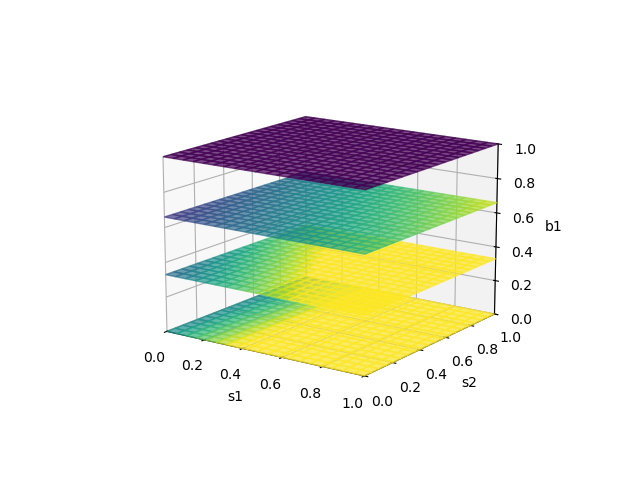

In [107]:
# Itaconic Acid Stoichiometries

from matplotlib.patches import Rectangle
import mpl_toolkits.mplot3d.art3d as art3d

cmap=plt.colormaps['viridis']

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

n = 20

s1Graduations = np.linspace(0,1,n)[0:n-1]
s2Graduations = np.linspace(0,1,n)[0:n-1]

b1_sca = 0.0

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Upper = s1Grad_sca + (1/(n-1))
        s1Lower = s1Grad_sca
        s2Upper = s2Grad_sca + (1/(n-1))
        s2Lower = s2Grad_sca

        samples = 10
        s1values = []
        s2values = []
        for i in range(samples):
            s1values.append(random.random() * (s1Upper - s1Lower) + s1Lower)
            s2values.append(random.random() * (s2Upper - s2Lower) + s2Lower)
        nCiValues = []
        for i,j in zip(s1values,s2values):
            nCiValues.append(nIt_func(s1Grad_sca,b1_sca,nCi_Range_lis))
        nCiAverageValue = np.average(nCiValues)
        BuiltRow.append(nCiAverageValue)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

b1_sca = 0.33

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Grad_sca = s1Grad_sca+(1/(n-1))/2
        s2Grad_sca = s2Grad_sca+(1/(n-1))/2
        nCi_sca = nIt_func(s1Grad_sca,b1_sca,nCi_Range_lis)
        BuiltRow.append(nCi_sca)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

b1_sca = 0.66

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Grad_sca = s1Grad_sca+(1/(n-1))/2
        s2Grad_sca = s2Grad_sca+(1/(n-1))/2
        nCi_sca = nIt_func(s1Grad_sca,b1_sca,nCi_Range_lis)
        BuiltRow.append(nCi_sca)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

b1_sca = 1.0

BuiltArray = []
for i,s1Grad_sca in enumerate(s1Graduations):
    BuiltRow = []
    for j,s2Grad_sca in enumerate(s2Graduations):
        s1Grad_sca = s1Grad_sca+(1/(n-1))/2
        s2Grad_sca = s2Grad_sca+(1/(n-1))/2
        nCi_sca = nIt_func(s1Grad_sca,b1_sca,nCi_Range_lis)
        BuiltRow.append(nCi_sca)
    BuiltArray.append(BuiltRow)
BuiltNumpyArray = np.array(BuiltArray)

for ii, row in zip(s1Graduations,BuiltNumpyArray):
    for jj, value in zip(s2Graduations,row):
        r = Rectangle((ii, jj), 1/(n-1), 1/(n-1), color=cmap(value), alpha=0.7)
        ax.add_patch(r)
        art3d.pathpatch_2d_to_3d(r, z=b1_sca, zdir="z")

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)
ax.get_figure().canvas.draw()
ax.set_xlabel("s1")
ax.set_ylabel("s2")
ax.set_zlabel("b1")

# ax.view_init(elev=90, azim=0)
ax.view_init(elev=15, azim=-55)

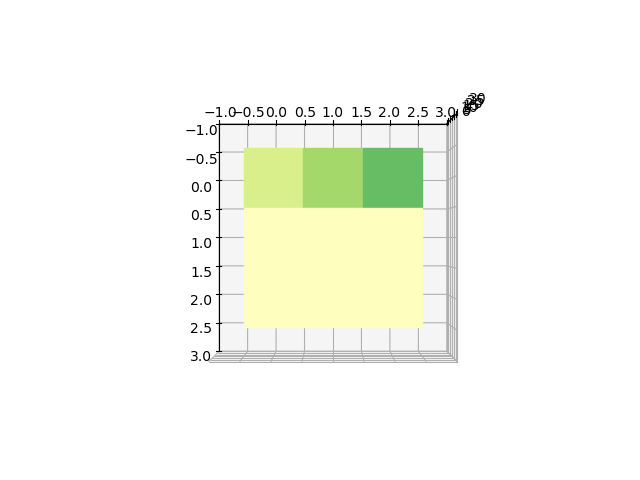

In [ ]:
# Ratio Between the two Stoichiometries

